In [1]:
import pandas as pd


In [2]:
pip install matplotlib plotly

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [3]:
import matplotlib.pyplot as plt

In [4]:
olx=pd.read_csv("../data/processed/olx_cleaned.csv")
ebay=pd.read_csv("../data/processed/ebay_cleaned.csv") 
used=pd.read_csv("../data/processed/used_devices_cleaned.csv")

In [5]:
print (olx.shape)
print(ebay.shape)
print(used.shape)
print(olx.columns)
print(ebay.columns)
print(used.columns)

(3931, 11)
(17577, 30)
(3454, 15)
Index(['Unnamed: 0', 'categoryName', 'userName', 'dateJoined', 'location',
       'price', 'title', 'brand', 'condition', 'description', 'adId'],
      dtype='str')
Index(['Uniq Id', 'Crawl Timestamp', 'Pageurl', 'Website', 'Title',
       'Num Of Reviews', 'Average Rating', 'Number Of Ratings', 'Model Num',
       'Sku', 'Upc', 'Manufacturer', 'Model Name', 'Price', 'Monthly Price',
       'Stock', 'Carrier', 'Color Category', 'Internal Memory', 'Screen Size',
       'Specifications', 'Five Star', 'Four Star', 'Three Star', 'Two Star',
       'One Star', 'Discontinued', 'Broken Link', 'Seller Rating',
       'Seller Num Of Reviews'],
      dtype='str')
Index(['brand_name', 'os', 'screen_size', '4g', '5g', 'main_camera_mp',
       'selfie_camera_mp', 'int_memory', 'ram', 'battery', 'weight',
       'release_year', 'days_used', 'normalized_used_price',
       'normalized_new_price'],
      dtype='str')


In [6]:
print(ebay["Price"].dtype)
print(ebay["Price"].head(10))


str
0    $369.08
1    $245.00
2    $431.24
3    $108.73
4    $200.00
5    $189.00
6     $16.95
7      $7.24
8     $14.50
9     $27.52
Name: Price, dtype: str


In [7]:
ebay["Price"]=ebay["Price"].str.replace("$","",regex=False)
ebay["Price"]=pd.to_numeric(ebay["Price"], errors="coerce")

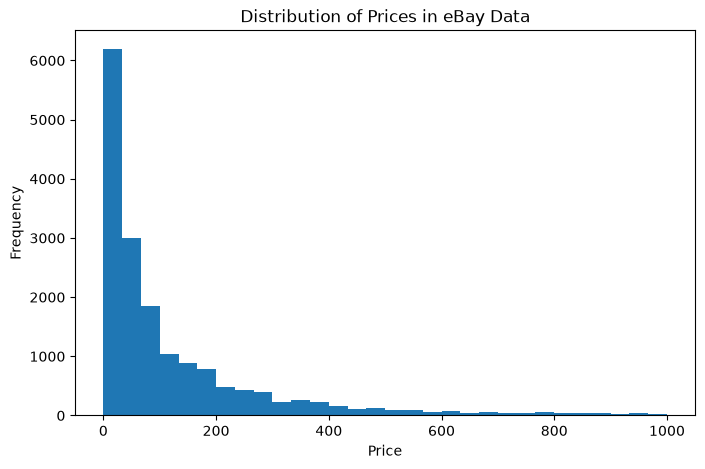

In [8]:
plt.figure(figsize=(8,5))
plt.hist(ebay["Price"].dropna(),bins=30)
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.title("Distribution of Prices in eBay Data")
plt.show()

In [9]:
print(olx["price"].dtype)
print(olx["price"].head(10))
print(type(olx["price"].iloc[0]))


str
0    Rs 115,000
1      Rs 9,999
2    Rs 122,000
3    Rs 215,000
4     Rs 18,499
5    Rs 220,000
6     Rs 95,000
7    Rs 215,000
8    Rs 218,000
9     Rs 53,000
Name: price, dtype: str
<class 'str'>


In [10]:
olx["price"]=olx["price"].str.replace("Rs","",regex=False).str.replace(",","",regex=False).str.strip()
olx["price"]=pd.to_numeric(olx["price"], errors="coerce")

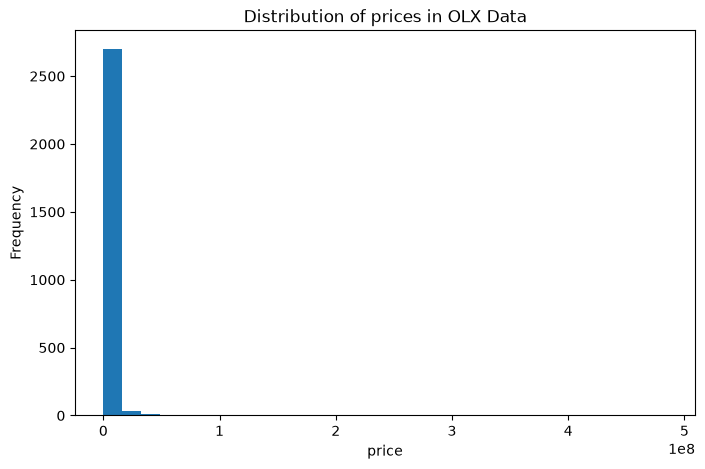

In [11]:
plt.figure(figsize=(8,5))
plt.hist(olx["price"].dropna(),bins=30)
plt.xlabel("price")
plt.ylabel("Frequency")
plt.title("Distribution of prices in OLX Data")
plt.show()

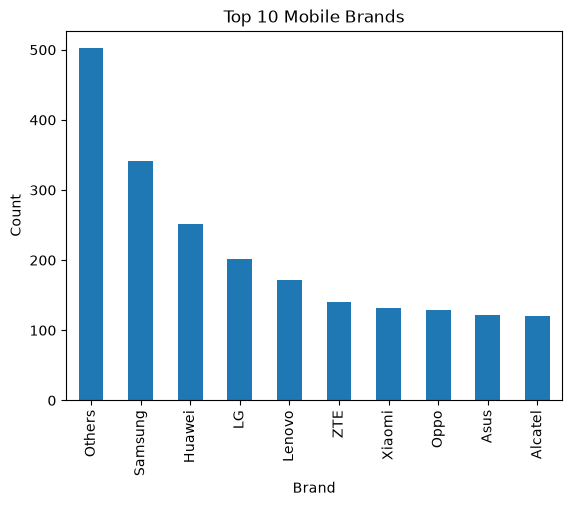

In [13]:
used["brand_name"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 Mobile Brands")
plt.xlabel("Brand")
plt.ylabel("Count")
plt.show()

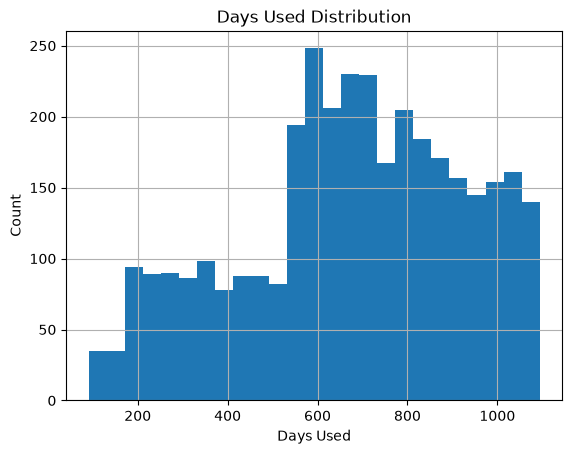

In [14]:
used["days_used"].hist(bins=25)
plt.title("Days Used Distribution")
plt.xlabel("Days Used")
plt.ylabel("Count")
plt.show()

In [15]:
numeric = used.select_dtypes(include="number")
numeric.corr()

,screen_size,main_camera_mp,selfie_camera_mp,int_memory,ram,battery,weight,release_year,days_used,normalized_used_price,normalized_new_price
screen_size,1.000000,0.139385,0.271615,0.071746,0.273810,0.811240,0.828872,0.364223,-0.291723,0.614785,0.460889
main_camera_mp,0.139385,1.000000,0.373565,0.009507,0.211150,0.225791,-0.088483,0.301558,-0.108173,0.552477,0.512655
selfie_camera_mp,0.271615,0.373565,1.000000,0.296531,0.477191,0.369661,-0.004688,0.690661,-0.552377,0.607548,0.474444
int_memory,0.071746,0.009507,0.296531,1.000000,0.122774,0.118108,0.015374,0.235166,-0.242377,0.190954,0.196067
ram,0.273810,0.211150,0.477191,0.122774,1.000000,0.280224,0.089901,0.313829,-0.279737,0.518783,0.530363
battery,0.811240,0.225791,0.369661,0.118108,0.280224,1.000000,0.699772,0.488496,-0.370623,0.612041,0.469762
weight,0.828872,-0.088483,-0.004688,0.015374,0.089901,0.699772,1.000000,0.071492,-0.067747,0.382456,0.269694
release_year,0.364223,0.301558,0.690661,0.235166,0.313829,0.488496,0.071492,1.000000,-0.750390,0.509790,0.303689
days_used,-0.291723,-0.108173,-0.552377,-0.242377,-0.279737,-0.370623,-0.067747,-0.750390,1.000000,-0.358264,-0.216625
normalized_used_price,0.614785,0.552477,0.607548,0.190954,0.518783,0.612041,0.382456,0.509790,-0.358264,1.000000,0.834496
